In [6]:
import os

# Check if data files exist (e.g., Magnetic.dat)
if not os.path.exists("Magnetic.dat"):
    print("Data files not found. Cloning repository...")
    !git clone https://github.com/Dr-UmairKhan/Makran-Seismic-OWF.git tmp_repo
    !cp -r tmp_repo/* ./
    !rm -rf tmp_repo
    print("Done. Now running the analysis...")
else:
    print("Data files found. Proceeding directly.")

Data files found. Proceeding directly.


Data: 6476 points, high-energy = 159
Training Logistic...
Training RF...
Training XGBoost...
Training GBM...
Training SVM...


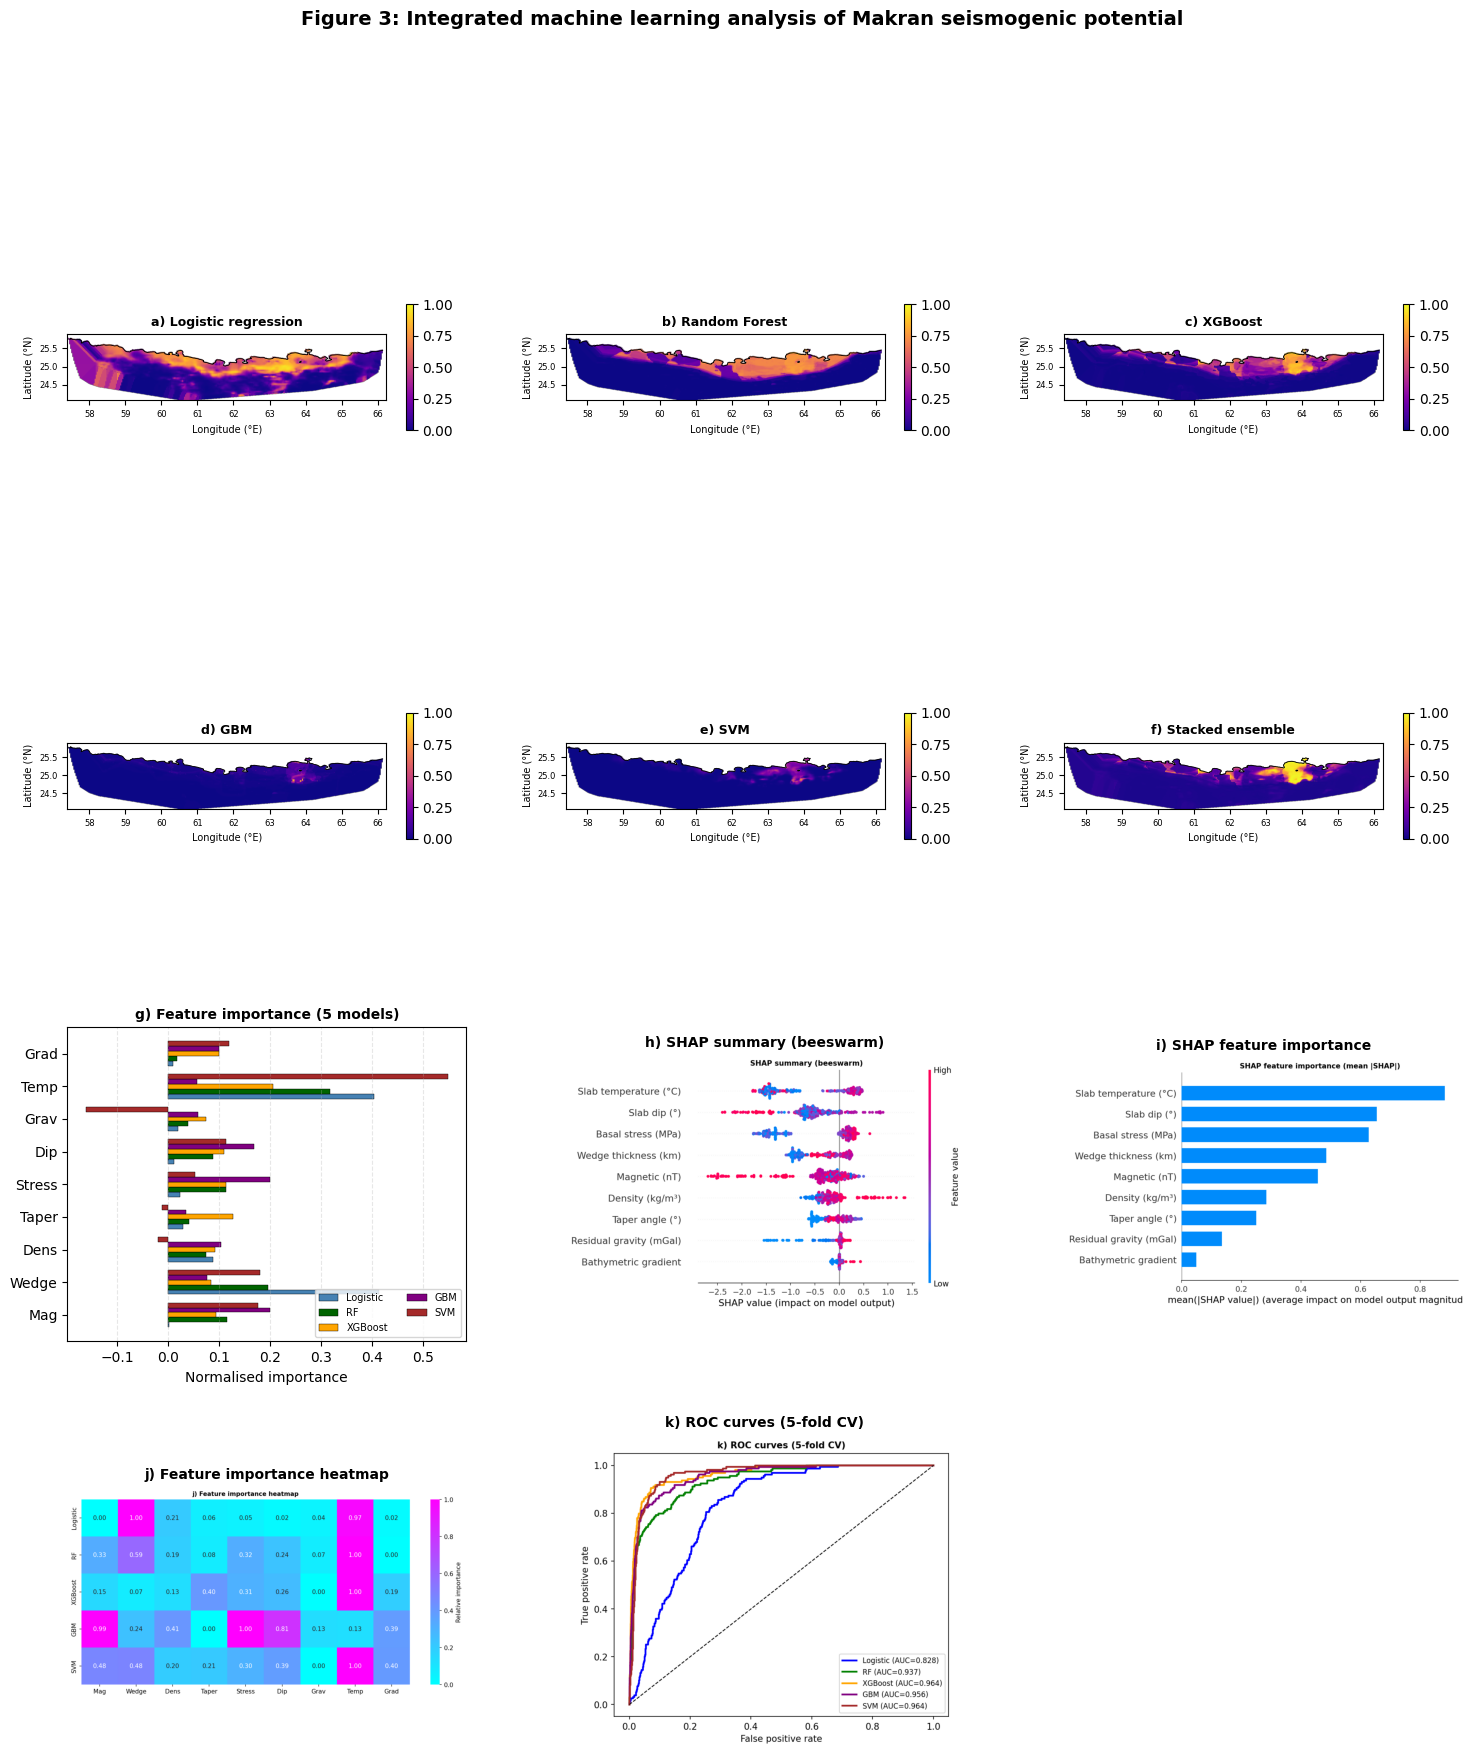

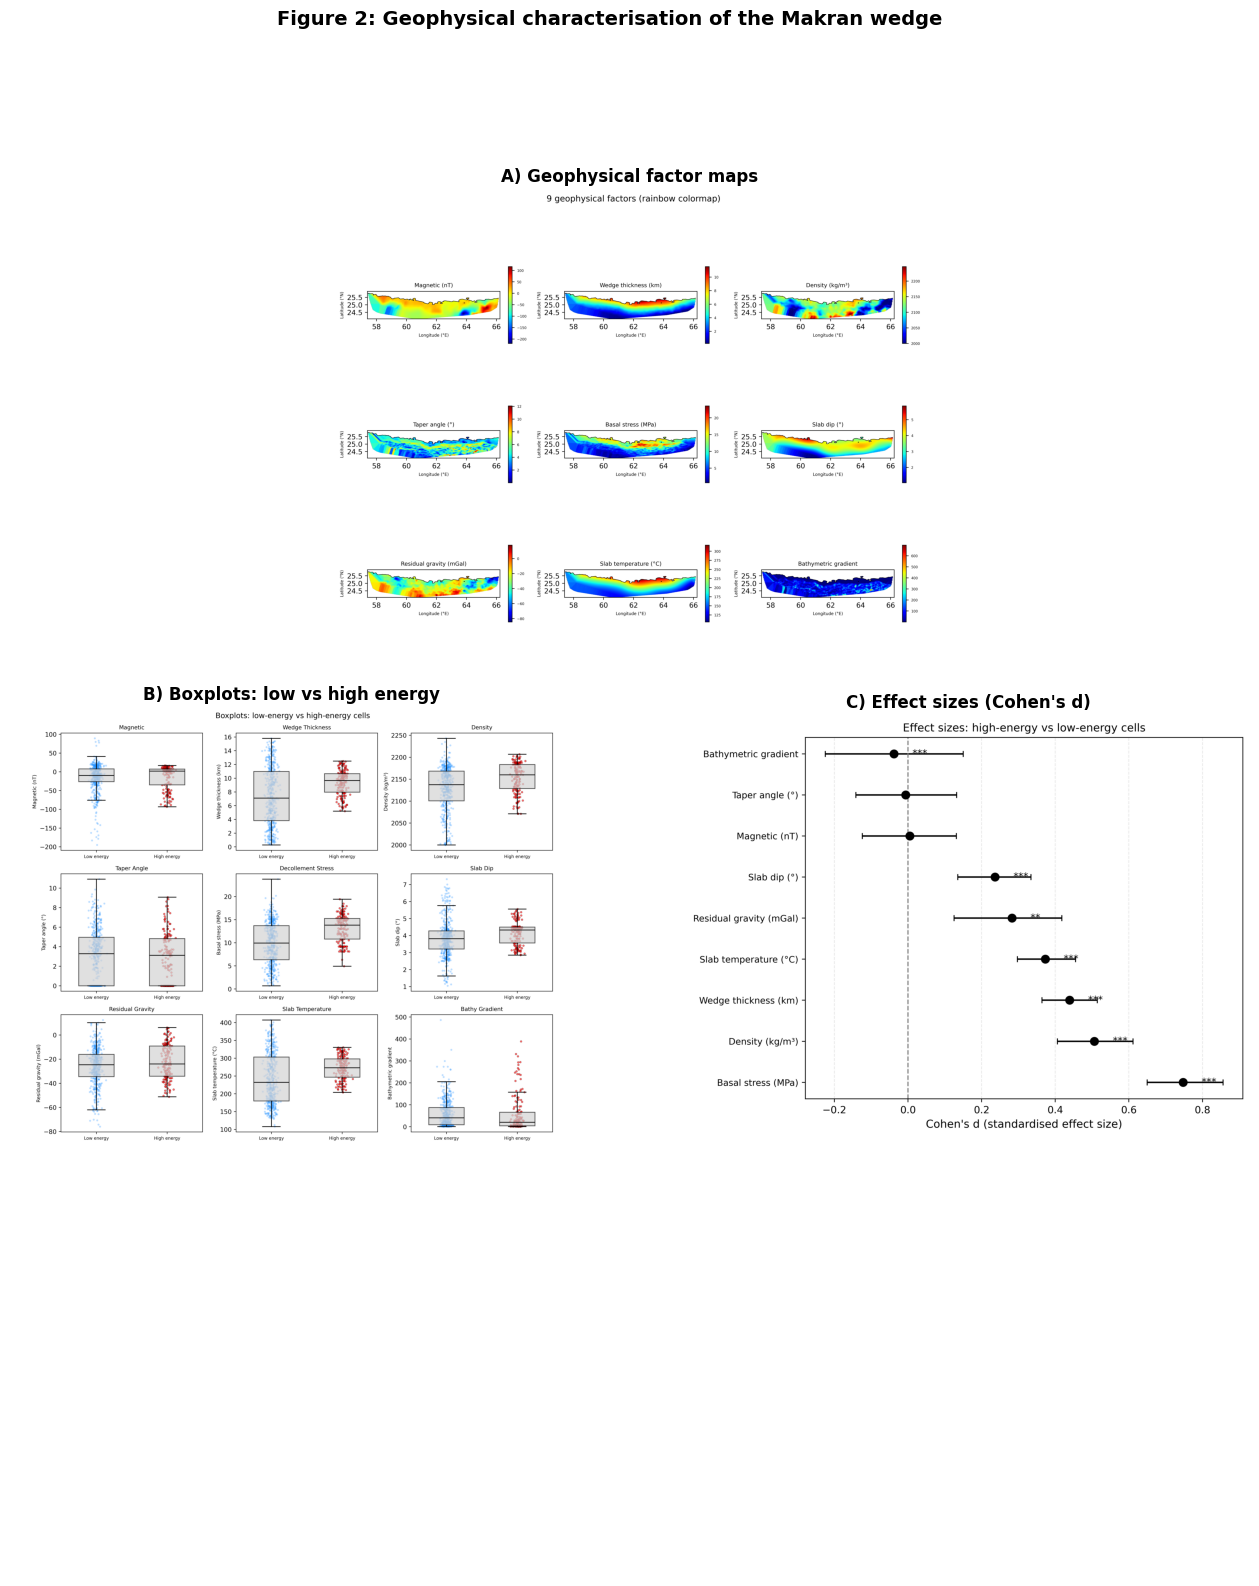

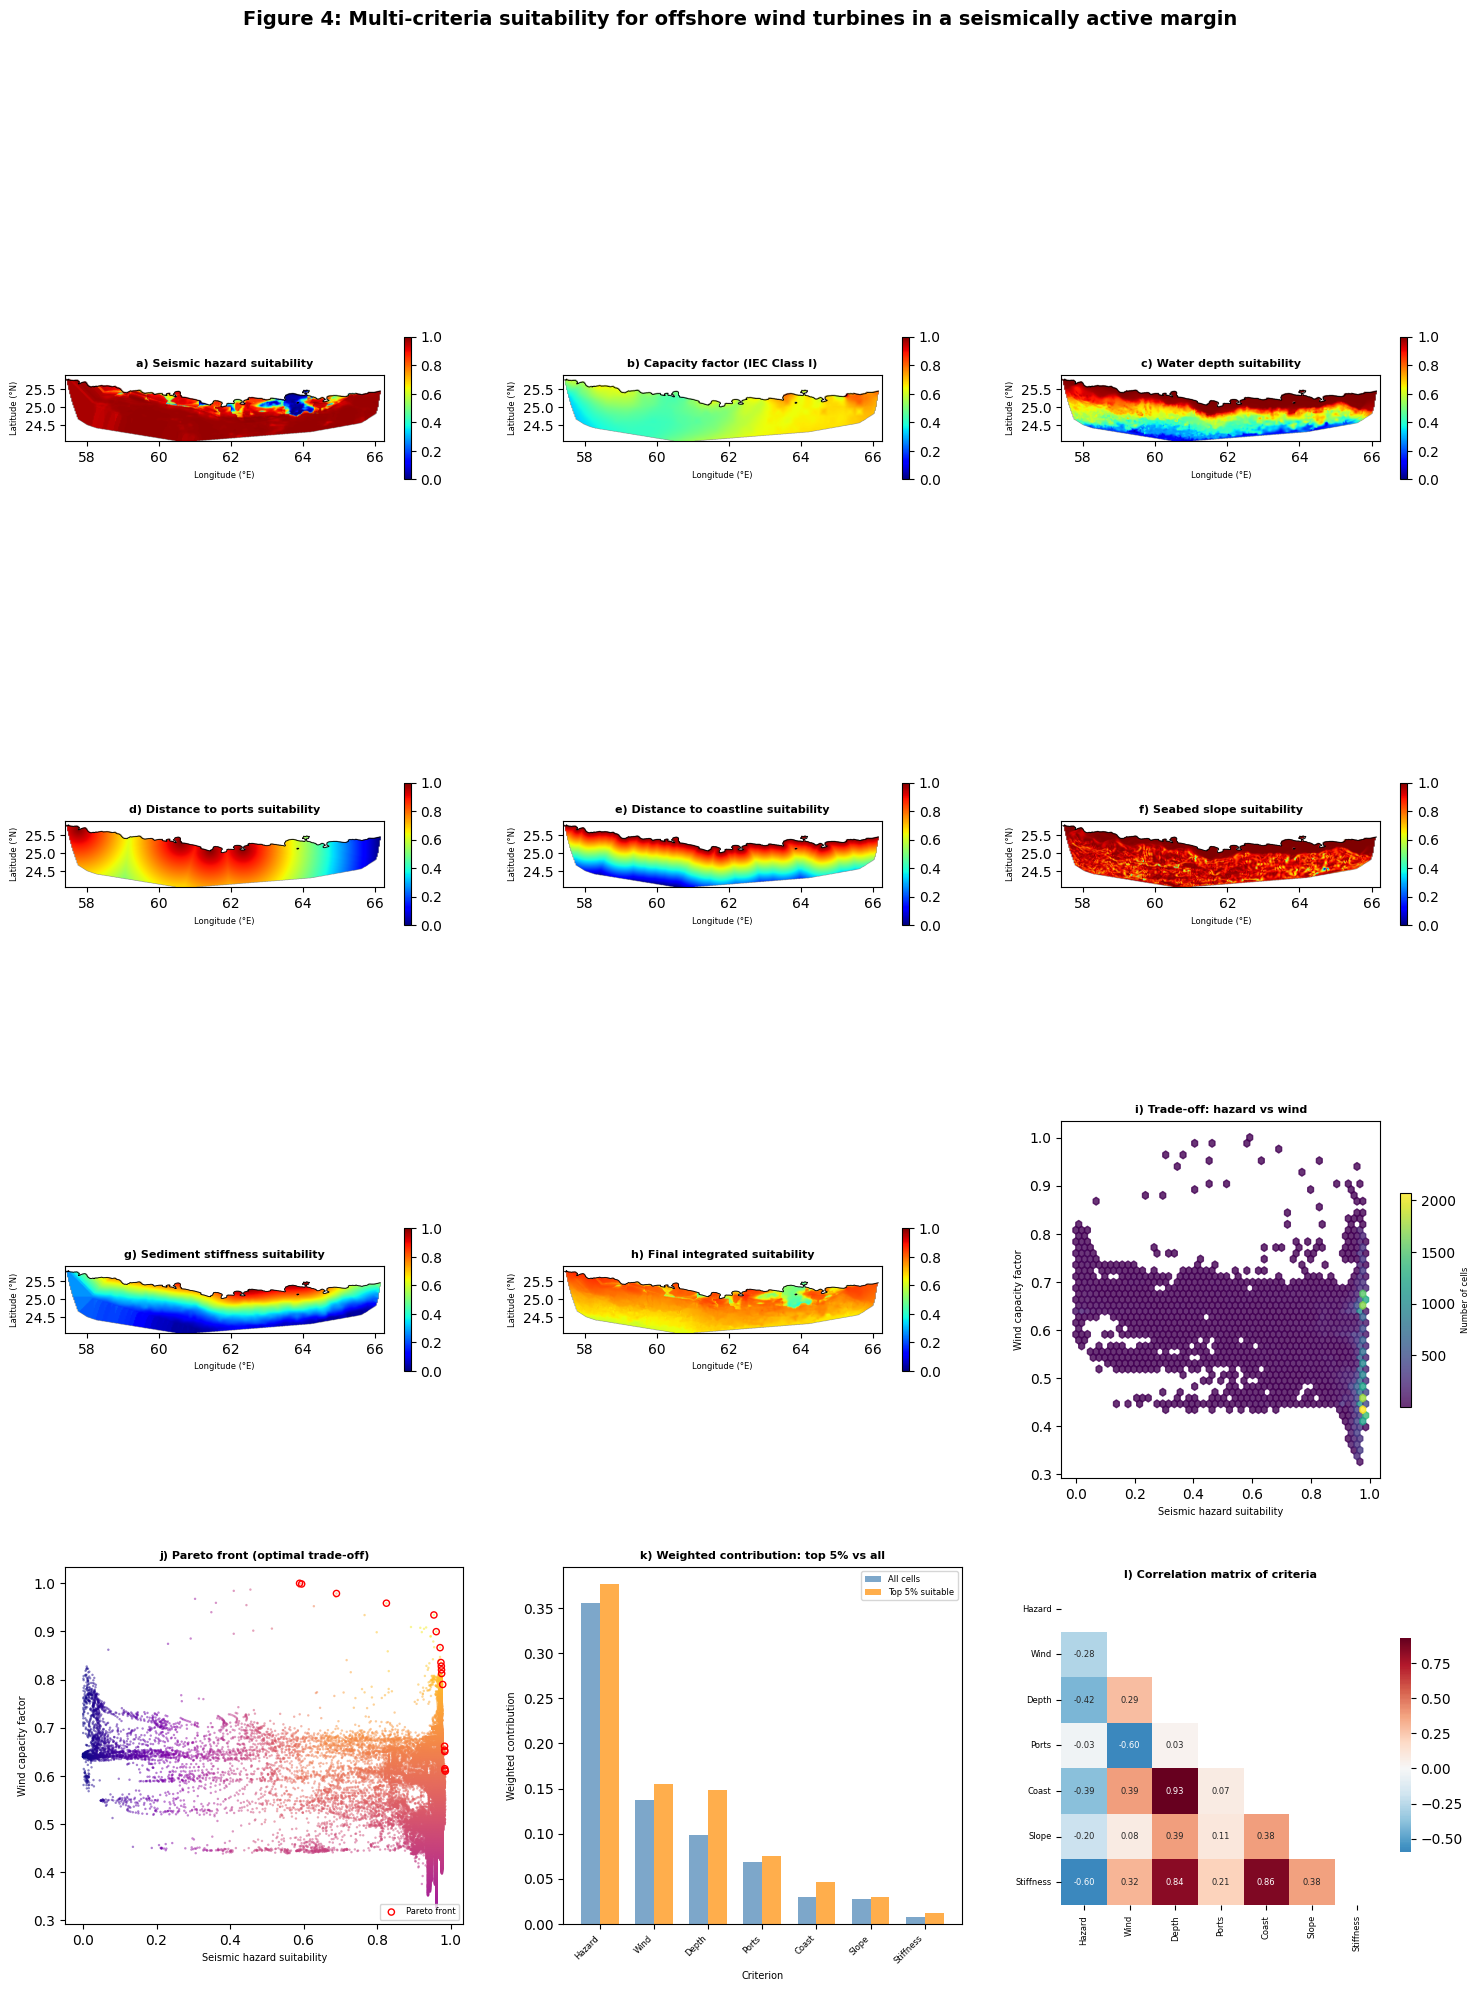


✅ All figures and tables saved to: ./output_figures
   - Figure 2: Figure2_Composite.png/.pdf
   - Figure 3: Figure3_Regenerated.png/.pdf
   - Extended Figure 4: Figure4_Extended.png/.pdf
   - Tables: 6 CSV files


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from scipy.interpolate import griddata
from scipy.spatial.distance import cdist
from skimage import measure
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
import xgboost as xgb
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc, roc_auc_score, average_precision_score
from sklearn.metrics import confusion_matrix, precision_recall_curve
from sklearn.inspection import permutation_importance
from sklearn.utils import resample
from scipy.stats import mannwhitneyu
import seaborn as sns
import shap
import os
import warnings
warnings.filterwarnings('ignore')

def load_xyz(filepath):
    with open(filepath, 'r') as f:
        first_line = f.readline().strip()
    try:
        float(first_line.split()[0])
        skiprows = 0
    except ValueError:
        skiprows = 1
    data = np.loadtxt(filepath, skiprows=skiprows)
    return data[:,0], data[:,1], data[:,2]

# 1) Load factor data and define target

data_dir = "."   # adjust if needed

factor_files = {
    'Magnetic': 'Magnetic.dat',
    'Wedge_Thickness': 'Accretionary-Wedge Thickness (Km).dat',
    'Density': 'Bulk Density (Kg per m3).dat',
    'Taper_Angle': 'Taper Angle (Deg.).dat',
    'Decollement_Stress': 'Shear Stress (MPA).dat',
    'Slab_Dip': 'Slab Dip (Deg.).dat',
    'Residual_Gravity': 'Residual Gravity.dat',
    'Slab_Temperature': 'Slab Tempreture (Deg.C).dat'
}
bathy_file = 'Bathemetry (m).dat'
energy_file = 'Cumulative energy release (log energy release (J)).dat'

# Reference grid from Magnetic
ref_lon, ref_lat, ref_val = load_xyz(os.path.join(data_dir, factor_files['Magnetic']))
df = pd.DataFrame({'Lon': ref_lon, 'Lat': ref_lat})
df['Magnetic'] = ref_val

for name, fname in factor_files.items():
    if name == 'Magnetic': continue
    x, y, z = load_xyz(os.path.join(data_dir, fname))
    interp = griddata((x, y), z, (ref_lon, ref_lat), method='linear')
    if np.any(np.isnan(interp)):
        interp_nearest = griddata((x, y), z, (ref_lon, ref_lat), method='nearest')
        interp[np.isnan(interp)] = interp_nearest[np.isnan(interp)]
    df[name] = interp

# Bathymetric gradient (9th factor)
x_b, y_b, z_b = load_xyz(os.path.join(data_dir, bathy_file))
xi_g = np.linspace(x_b.min(), x_b.max(), 200)
yi_g = np.linspace(y_b.min(), y_b.max(), 200)
Xi_g, Yi_g = np.meshgrid(xi_g, yi_g)
bathy_grid_coarse = griddata((x_b, y_b), z_b, (Xi_g, Yi_g), method='linear')
dy, dx = np.gradient(bathy_grid_coarse)
slope = np.sqrt(dx**2 + dy**2)
slope_at_points = griddata((Xi_g.flatten(), Yi_g.flatten()), slope.flatten(),
                           (ref_lon, ref_lat), method='linear')
df['Bathy_Gradient'] = slope_at_points

# Target
x_e, y_e, z_e = load_xyz(os.path.join(data_dir, energy_file))
pos_mask = z_e > 0
logE_at_points = np.log10(z_e[pos_mask])
lon_pos = x_e[pos_mask]
lat_pos = y_e[pos_mask]
logE_int = griddata((lon_pos, lat_pos), logE_at_points, (ref_lon, ref_lat), method='linear')
df['logE'] = logE_int
threshold = 16.7
df['high_energy'] = (df['logE'] > threshold) & (df['logE'].notna())

factors = list(factor_files.keys()) + ['Bathy_Gradient']
nice_labels = ['Magnetic (nT)', 'Wedge thickness (km)', 'Density (kg/m³)', 'Taper angle (°)',
               'Basal stress (MPa)', 'Slab dip (°)', 'Residual gravity (mGal)', 'Slab temperature (°C)',
               'Bathymetric gradient']
short_labels = ['Mag', 'Wedge', 'Dens', 'Taper', 'Stress', 'Dip', 'Grav', 'Temp', 'Grad']

df_clean = df.dropna(subset=factors + ['logE']).copy()
X = df_clean[factors].fillna(0).values
y = df_clean['high_energy'].astype(int).values
print(f"Data: {len(df_clean)} points, high-energy = {y.sum()}")

# 2) Train models and compute probability grids (for Figure 3)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

models = {
    'Logistic': LogisticRegression(class_weight='balanced', C=1.0, max_iter=1000, random_state=42),
    'RF': RandomForestClassifier(n_estimators=50, max_depth=5, min_samples_split=10, class_weight='balanced', random_state=42),
    'XGBoost': xgb.XGBClassifier(n_estimators=50, max_depth=3, learning_rate=0.1, reg_lambda=1.0,
                                 scale_pos_weight=(len(y)-y.sum())/y.sum(),
                                 random_state=42, use_label_encoder=False, eval_metric='logloss'),
    'GBM': GradientBoostingClassifier(n_estimators=50, max_depth=3, random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_probs = {name: np.zeros(len(y)) for name in models}
for name, clf in models.items():
    print(f"Training {name}...")
    for train_idx, test_idx in cv.split(X_scaled, y):
        X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        clf.fit(X_train, y_train)
        oof_probs[name][test_idx] = clf.predict_proba(X_test)[:, 1]

X_meta = np.column_stack([oof_probs[name] for name in models])
meta_model = LogisticRegression(class_weight='balanced', C=1.0, max_iter=1000, random_state=42)
meta_model.fit(X_meta, y)
stacked_oof = meta_model.predict_proba(X_meta)[:, 1]

# 3) Regular grid (bathymetry) for all maps
x_b, y_b, z_b = load_xyz(os.path.join(data_dir, bathy_file))
xi = np.linspace(x_b.min(), x_b.max(), 300)
yi = np.linspace(y_b.min(), y_b.max(), 300)
Xi, Yi = np.meshgrid(xi, yi)
bathy_grid_full = griddata((x_b, y_b), z_b, (Xi, Yi), method='linear')
offshore_mask = bathy_grid_full < 0

# Interpolate all factors onto grid
factor_grids = {}
for f in factors:
    grid_f = griddata((df_clean['Lon'], df_clean['Lat']), df_clean[f], (Xi, Yi), method='linear')
    mask_nan = np.isnan(grid_f)
    if mask_nan.any():
        grid_f[mask_nan] = griddata((df_clean['Lon'], df_clean['Lat']), df_clean[f], (Xi, Yi), method='nearest')[mask_nan]
    factor_grids[f] = grid_f

ny, nx = Xi.shape
X_grid = np.zeros((ny, nx, len(factors)))
for i, f in enumerate(factors):
    X_grid[:,:,i] = factor_grids[f]
X_grid_flat = X_grid.reshape(-1, len(factors))
valid_rows = ~np.isnan(X_grid_flat).any(axis=1)
X_grid_valid = X_grid_flat[valid_rows]
X_grid_scaled = scaler.transform(X_grid_valid)

# Probability grids
prob_logreg = np.full((ny, nx), np.nan)
prob_rf = np.full((ny, nx), np.nan)
prob_xgb = np.full((ny, nx), np.nan)
prob_gbm = np.full((ny, nx), np.nan)
prob_svm = np.full((ny, nx), np.nan)

prob_logreg.flat[valid_rows] = models['Logistic'].predict_proba(X_grid_scaled)[:,1]
prob_rf.flat[valid_rows] = models['RF'].predict_proba(X_grid_scaled)[:,1]
prob_xgb.flat[valid_rows] = models['XGBoost'].predict_proba(X_grid_scaled)[:,1]
prob_gbm.flat[valid_rows] = models['GBM'].predict_proba(X_grid_scaled)[:,1]
prob_svm.flat[valid_rows] = models['SVM'].predict_proba(X_grid_scaled)[:,1]

valid_mask = np.ones((ny, nx), dtype=bool)
for prob in [prob_logreg, prob_rf, prob_xgb, prob_gbm, prob_svm]:
    valid_mask &= ~np.isnan(prob)
valid_mask &= offshore_mask
valid_indices = np.where(valid_mask)
X_meta_grid = np.column_stack([prob[valid_indices] for prob in [prob_logreg, prob_rf, prob_xgb, prob_gbm, prob_svm]])
stacked_valid = meta_model.predict_proba(X_meta_grid)[:,1]
stacked_prob = np.full((ny, nx), np.nan)
stacked_prob[valid_indices] = stacked_valid

for prob in [prob_logreg, prob_rf, prob_xgb, prob_gbm, prob_svm, stacked_prob]:
    prob[:] = np.where(offshore_mask, prob, np.nan)

# 4) Feature importances and SHAP (for Figure 3)
imp_logreg = np.abs(models['Logistic'].coef_[0]) / np.sum(np.abs(models['Logistic'].coef_[0]))
imp_rf = models['RF'].feature_importances_ / np.sum(models['RF'].feature_importances_)
imp_xgb = models['XGBoost'].feature_importances_ / np.sum(models['XGBoost'].feature_importances_)
imp_gbm = models['GBM'].feature_importances_ / np.sum(models['GBM'].feature_importances_)
idx_sample = np.random.choice(len(y), 500, replace=False)
perm_svm = permutation_importance(models['SVM'], X_scaled[idx_sample], y[idx_sample], n_repeats=5, random_state=42)
imp_svm = perm_svm.importances_mean / np.sum(perm_svm.importances_mean)

# SHAP
xgb_model = models['XGBoost']
explainer = shap.TreeExplainer(xgb_model)
shap_vals = explainer.shap_values(X_scaled)
if isinstance(shap_vals, list):
    shap_vals = shap_vals[1]
sample_idx = np.random.choice(len(X_scaled), min(500, len(X_scaled)), replace=False)
X_sample = X_scaled[sample_idx]
shap_sample = shap_vals[sample_idx]

shap_beeswarm_path = '/tmp/shap_beeswarm.png'
shap_bar_path = '/tmp/shap_bar.png'
plt.figure(figsize=(8,5))
shap.summary_plot(shap_sample, X_sample, feature_names=nice_labels, show=False)
plt.title('SHAP summary (beeswarm)', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(shap_beeswarm_path, dpi=150, bbox_inches='tight')
plt.close()
plt.figure(figsize=(6,4))
shap.summary_plot(shap_sample, X_sample, feature_names=nice_labels, plot_type='bar', show=False)
plt.title('SHAP feature importance (mean |SHAP|)', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(shap_bar_path, dpi=150, bbox_inches='tight')
plt.close()
shap_beeswarm_img = plt.imread(shap_beeswarm_path)
shap_bar_img = plt.imread(shap_bar_path)

# Heatmap
imp_df = pd.DataFrame({
    'Logistic': imp_logreg,
    'RF': imp_rf,
    'XGBoost': imp_xgb,
    'GBM': imp_gbm,
    'SVM': imp_svm
}, index=short_labels).T
scaler_mm = MinMaxScaler()
imp_scaled = pd.DataFrame(scaler_mm.fit_transform(imp_df.T).T, index=imp_df.index, columns=imp_df.columns)
fig_heat, ax_heat = plt.subplots(figsize=(10,5))
sns.heatmap(imp_scaled, annot=True, fmt='.2f', cmap='cool', ax=ax_heat, cbar_kws={'label': 'Relative importance'})
ax_heat.set_title('j) Feature importance heatmap', fontsize=10, fontweight='bold')
plt.tight_layout()
heatmap_path = '/tmp/heatmap.png'
plt.savefig(heatmap_path, dpi=150, bbox_inches='tight')
plt.close()
heatmap_img = plt.imread(heatmap_path)

# ROC curves
fig_roc, ax_roc = plt.subplots(figsize=(6,5))
colors_roc = {'Logistic':'blue', 'RF':'green', 'XGBoost':'orange', 'GBM':'purple', 'SVM':'brown'}
for name, probs in oof_probs.items():
    fpr, tpr, _ = roc_curve(y, probs)
    auc_val = auc(fpr, tpr)
    ax_roc.plot(fpr, tpr, color=colors_roc.get(name, 'gray'), lw=2, label=f'{name} (AUC={auc_val:.3f})')
ax_roc.plot([0,1], [0,1], 'k--', lw=1)
ax_roc.set_xlabel('False positive rate')
ax_roc.set_ylabel('True positive rate')
ax_roc.set_title('k) ROC curves (5‑fold CV)', fontsize=10, fontweight='bold')
ax_roc.legend(loc='lower right', fontsize=8)
plt.tight_layout()
roc_path = '/tmp/roc.png'
plt.savefig(roc_path, dpi=150, bbox_inches='tight')
plt.close()
roc_img = plt.imread(roc_path)

def plot_feature_importance(ax):
    x_pos = np.arange(len(short_labels))
    width = 0.15
    offsets = [-0.3, -0.15, 0.0, 0.15, 0.3]
    imps = [imp_logreg, imp_rf, imp_xgb, imp_gbm, imp_svm]
    model_names = ['Logistic', 'RF', 'XGBoost', 'GBM', 'SVM']
    colors_imp = {'Logistic':'steelblue', 'RF':'darkgreen', 'XGBoost':'orange', 'GBM':'purple', 'SVM':'brown'}
    for i, (name, imp) in enumerate(zip(model_names, imps)):
        ax.barh(x_pos + offsets[i], imp[:9], width, label=name, color=colors_imp[name], edgecolor='black', linewidth=0.3)
    ax.set_yticks(x_pos)
    ax.set_yticklabels(short_labels)
    ax.set_xlabel('Normalised importance')
    ax.set_title('g) Feature importance (5 models)', fontsize=10, fontweight='bold')
    ax.legend(loc='lower right', fontsize=7, ncol=2)
    ax.grid(axis='x', linestyle='--', alpha=0.3)

def add_map(ax, prob_grid, title):
    im = ax.imshow(prob_grid, origin='lower', extent=[xi.min(), xi.max(), yi.min(), yi.max()],
                   cmap='plasma', vmin=0, vmax=1, interpolation='bilinear')
    ax.contour(Xi, Yi, bathy_grid_full, levels=[0], colors='k', linewidths=0.6)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_xlabel('Longitude (°E)', fontsize=7)
    ax.set_ylabel('Latitude (°N)', fontsize=7)
    ax.tick_params(labelsize=6)
    plt.colorbar(im, ax=ax, shrink=0.4, pad=0.05)
    return im

out_dir = "./output_figures"
tables_dir = "./output_tables"
os.makedirs(tables_dir, exist_ok=True)
os.makedirs(out_dir, exist_ok=True)

# 5) Figure 3 (probability maps + ML diagnostics)
fig3 = plt.figure(figsize=(18, 20))
gs = GridSpec(4, 3, figure=fig3, hspace=0.3, wspace=0.25, height_ratios=[1,1,1,1])

ax1 = fig3.add_subplot(gs[0,0]); add_map(ax1, prob_logreg, 'a) Logistic regression')
ax2 = fig3.add_subplot(gs[0,1]); add_map(ax2, prob_rf, 'b) Random Forest')
ax3 = fig3.add_subplot(gs[0,2]); add_map(ax3, prob_xgb, 'c) XGBoost')
ax4 = fig3.add_subplot(gs[1,0]); add_map(ax4, prob_gbm, 'd) GBM')
ax5 = fig3.add_subplot(gs[1,1]); add_map(ax5, prob_svm, 'e) SVM')
ax6 = fig3.add_subplot(gs[1,2]); add_map(ax6, stacked_prob, 'f) Stacked ensemble')

ax7 = fig3.add_subplot(gs[2,0]); plot_feature_importance(ax7)
ax8 = fig3.add_subplot(gs[2,1]); ax8.imshow(shap_beeswarm_img); ax8.axis('off'); ax8.set_title('h) SHAP summary (beeswarm)', fontsize=10, fontweight='bold')
ax9 = fig3.add_subplot(gs[2,2]); ax9.imshow(shap_bar_img); ax9.axis('off'); ax9.set_title('i) SHAP feature importance', fontsize=10, fontweight='bold')

ax10 = fig3.add_subplot(gs[3,0]); ax10.imshow(heatmap_img); ax10.axis('off'); ax10.set_title('j) Feature importance heatmap', fontsize=10, fontweight='bold')
ax11 = fig3.add_subplot(gs[3,1]); ax11.imshow(roc_img); ax11.axis('off'); ax11.set_title('k) ROC curves (5‑fold CV)', fontsize=10, fontweight='bold')
ax12 = fig3.add_subplot(gs[3,2]); ax12.axis('off')

plt.suptitle('Figure 3: Integrated machine learning analysis of Makran seismogenic potential', fontsize=14, fontweight='bold', y=0.98)
plt.savefig(os.path.join(out_dir, 'Figure3_Regenerated.png'), dpi=500, bbox_inches='tight')
plt.savefig(os.path.join(out_dir, 'Figure3_Regenerated.pdf'), bbox_inches='tight')
plt.show()
plt.close(fig3)

# 6) Figure 2: Composite of factor maps + boxplots + forest plot
# 6a) Factor maps
fig2_maps, axes_maps = plt.subplots(3, 3, figsize=(12, 10))
axes_maps = axes_maps.flatten()
for i, (f, label) in enumerate(zip(factors, nice_labels)):
    ax = axes_maps[i]
    grid = factor_grids[f]
    grid_masked = np.where(offshore_mask, grid, np.nan)
    im = ax.imshow(grid_masked, origin='lower', extent=[xi.min(), xi.max(), yi.min(), yi.max()],
                   cmap='jet', interpolation='bilinear')
    ax.contour(Xi, Yi, bathy_grid_full, levels=[0], colors='k', linewidths=0.6)
    ax.set_title(label, fontsize=8)
    ax.set_xlabel('Longitude (°E)', fontsize=6)
    ax.set_ylabel('Latitude (°N)', fontsize=6)
    cbar = plt.colorbar(im, ax=ax, shrink=0.4, pad=0.05)
    cbar.ax.tick_params(labelsize=5)
plt.suptitle('9 geophysical factors (rainbow colormap)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'Fig2_FactorMaps.png'), dpi=500, bbox_inches='tight')
plt.close(fig2_maps)

# 6b) Boxplots + jitter
low = df_clean[df_clean['high_energy'] == False]
high = df_clean[df_clean['high_energy'] == True]
low_sample = low.sample(n=min(500, len(low)), random_state=42)

fig_box, axes_box = plt.subplots(3, 3, figsize=(12, 10))
axes_box = axes_box.flatten()
for i, (factor, label) in enumerate(zip(factors, nice_labels)):
    ax = axes_box[i]
    data_low = low_sample[factor].dropna()
    data_high = high[factor].dropna()
    ax.boxplot([data_low, data_high], positions=[1,2], widths=0.5, patch_artist=True,
               showfliers=False,
               boxprops=dict(facecolor='lightgray', alpha=0.7, linewidth=1.2),
               whiskerprops=dict(linewidth=1.2),
               capprops=dict(linewidth=1.2),
               medianprops=dict(linewidth=1.2, color='black'))
    ax.scatter(np.random.normal(1, 0.04, size=len(data_low)), data_low, s=10, c='dodgerblue', alpha=0.3, edgecolors='none')
    ax.scatter(np.random.normal(2, 0.04, size=len(data_high)), data_high, s=10, c='red', alpha=0.6, edgecolors='black', linewidth=0.3)
    ax.set_xticks([1,2])
    ax.set_xticklabels(['Low energy', 'High energy'], fontsize=8)
    ax.set_ylabel(label, fontsize=8)
    ax.set_title(factor.replace('_',' '), fontsize=9)
    ax.tick_params(axis='x', labelsize=7)
plt.suptitle('Boxplots: low‑energy vs high‑energy cells', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'Fig2_Boxplots.png'), dpi=500, bbox_inches='tight')
plt.close(fig_box)

# 6c) Cohen's d forest plot
cohen_results = []
for factor, label in zip(factors, nice_labels):
    x_low = low[factor].dropna().values
    x_high = high[factor].dropna().values
    if len(x_low)==0 or len(x_high)==0: continue
    s_pooled = np.sqrt(((len(x_low)-1)*np.std(x_low, ddof=1)**2 + (len(x_high)-1)*np.std(x_high, ddof=1)**2) / (len(x_low)+len(x_high)-2))
    d = (np.mean(x_high) - np.mean(x_low)) / s_pooled
    boot_d = []
    for _ in range(500):
        low_b = resample(x_low, replace=True)
        high_b = resample(x_high, replace=True)
        s_pool_b = np.sqrt(((len(low_b)-1)*np.std(low_b, ddof=1)**2 + (len(high_b)-1)*np.std(high_b, ddof=1)**2) / (len(low_b)+len(high_b)-2))
        d_b = (np.mean(high_b) - np.mean(low_b)) / s_pool_b
        boot_d.append(d_b)
    ci_low = np.percentile(boot_d, 2.5)
    ci_high = np.percentile(boot_d, 97.5)
    _, p = mannwhitneyu(x_low, x_high, alternative='two-sided')
    cohen_results.append((label, d, ci_low, ci_high, p))
df_cohen = pd.DataFrame(cohen_results, columns=['Factor', 'Cohen_d', 'CI_low', 'CI_high', 'p_value'])
df_cohen = df_cohen.sort_values('Cohen_d', ascending=False)
df_cohen['sig'] = ''
df_cohen.loc[df_cohen['p_value'] < 0.001, 'sig'] = '***'
df_cohen.loc[(df_cohen['p_value'] >= 0.001) & (df_cohen['p_value'] < 0.01), 'sig'] = '**'
df_cohen.loc[(df_cohen['p_value'] >= 0.01) & (df_cohen['p_value'] < 0.05), 'sig'] = '*'

fig_forest, ax_forest = plt.subplots(figsize=(8, 6))
y_pos = np.arange(len(df_cohen))
ax_forest.errorbar(df_cohen['Cohen_d'], y_pos,
                   xerr=[df_cohen['Cohen_d']-df_cohen['CI_low'], df_cohen['CI_high']-df_cohen['Cohen_d']],
                   fmt='o', color='black', ecolor='black', capsize=3, elinewidth=1.5, markersize=8)
ax_forest.axvline(0, linestyle='--', color='gray', linewidth=1.2)
ax_forest.set_yticks(y_pos)
ax_forest.set_yticklabels(df_cohen['Factor'], fontsize=9)
ax_forest.set_xlabel("Cohen's d (standardised effect size)", fontsize=11)
ax_forest.set_title("Effect sizes: high‑energy vs low‑energy cells", fontsize=11)
for i, (_, row) in enumerate(df_cohen.iterrows()):
    ax_forest.text(row['Cohen_d'] + 0.05, i, row['sig'], va='center', fontsize=10)
ax_forest.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'Fig2_ForestPlot.png'), dpi=500, bbox_inches='tight')
plt.close(fig_forest)

# Assemble Figure 2 composite
fig2_comp = plt.figure(figsize=(16, 18))
gs2 = GridSpec(3, 2, figure=fig2_comp, hspace=0.2, wspace=0.2, height_ratios=[1, 1, 0.8])
ax_top = fig2_comp.add_subplot(gs2[0, :])
factor_map_img = plt.imread(os.path.join(out_dir, 'Fig2_FactorMaps.png'))
ax_top.imshow(factor_map_img)
ax_top.axis('off')
ax_top.set_title('A) Geophysical factor maps', fontsize=12, fontweight='bold')
ax_mid_left = fig2_comp.add_subplot(gs2[1, 0])
boxplot_img = plt.imread(os.path.join(out_dir, 'Fig2_Boxplots.png'))
ax_mid_left.imshow(boxplot_img)
ax_mid_left.axis('off')
ax_mid_left.set_title('B) Boxplots: low vs high energy', fontsize=12, fontweight='bold')
ax_mid_right = fig2_comp.add_subplot(gs2[1, 1])
forest_img = plt.imread(os.path.join(out_dir, 'Fig2_ForestPlot.png'))
ax_mid_right.imshow(forest_img)
ax_mid_right.axis('off')
ax_mid_right.set_title('C) Effect sizes (Cohen\'s d)', fontsize=12, fontweight='bold')
ax_bottom = fig2_comp.add_subplot(gs2[2, :])
ax_bottom.axis('off')
plt.suptitle('Figure 2: Geophysical characterisation of the Makran wedge', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'Figure2_Composite.png'), dpi=500, bbox_inches='tight')
plt.savefig(os.path.join(out_dir, 'Figure2_Composite.pdf'), bbox_inches='tight')
plt.show()
plt.close(fig2_comp)

# 7) Extended Figure 4: Suitability maps + discussion panels (i-l)
# Load capacity factor
cf_file = None
for f in os.listdir(data_dir):
    if ('capacity' in f.lower() or 'factor' in f.lower()) and f.endswith('.dat'):
        cf_file = f
        break
if cf_file is None:
    raise FileNotFoundError("Capacity factor .dat file not found.")
x_cf, y_cf, z_cf = load_xyz(os.path.join(data_dir, cf_file))
cf_grid = griddata((x_cf, y_cf), z_cf, (Xi, Yi), method='linear')
suit_wind = cf_grid / np.nanmax(cf_grid[offshore_mask])
suit_wind = np.where(offshore_mask, suit_wind, np.nan)

suit_depth = 1 - (np.abs(bathy_grid_full) / np.nanmax(np.abs(bathy_grid_full[offshore_mask])))
suit_depth = np.where(offshore_mask, suit_depth, np.nan)

# Coastline distance
contours = measure.find_contours(bathy_grid_full, 0)
if len(contours) > 0:
    coastline = contours[0]
    lon_c = xi[0] + (coastline[:,1] / (len(xi)-1)) * (xi[-1] - xi[0])
    lat_c = yi[0] + (coastline[:,0] / (len(yi)-1)) * (yi[-1] - yi[0])
    coastline_xy = np.column_stack((lon_c, lat_c))
    grid_xy = np.column_stack((Xi.flatten(), Yi.flatten()))
    dist_coast = cdist(grid_xy, coastline_xy).min(axis=1).reshape(Xi.shape)
    dist_coast = np.where(offshore_mask, dist_coast, np.nan)
    suit_coast = 1 - (dist_coast / np.nanmax(dist_coast))
else:
    suit_coast = np.zeros_like(offshore_mask, dtype=float)

# Ports
port_file_path = os.path.join(data_dir, 'Ports Location.xlsx')
if os.path.exists(port_file_path):
    ports = pd.read_excel(port_file_path)
    lat_col = [c for c in ports.columns if 'lat' in c.lower()][0]
    lon_col = [c for c in ports.columns if 'lon' in c.lower()][0]
    port_coords = ports[[lon_col, lat_col]].values.astype(float)
else:
    port_coords = np.array([[62.3327,25.1206],[60.6022,25.2997],[57.7594,25.6494],[60.5994,25.3022],[61.4248,25.0667]])
dist_ports = cdist(grid_xy, port_coords).min(axis=1).reshape(Xi.shape)
dist_ports = np.where(offshore_mask, dist_ports, np.nan)
suit_ports = 1 - (dist_ports / np.nanmax(dist_ports))

# Slope
dy, dx = np.gradient(bathy_grid_full)
slope = np.sqrt(dx**2 + dy**2)
suit_slope = 1 - (slope / np.nanmax(slope[offshore_mask]))
suit_slope = np.where(offshore_mask, suit_slope, np.nan)

# Sediment stiffness
thick_grid = factor_grids['Wedge_Thickness']
thick_grid = np.where(offshore_mask, thick_grid, np.nan)
suit_stiffness = thick_grid / np.nanmax(thick_grid[offshore_mask])

suit_hazard = 1 - stacked_prob
suit_hazard = np.where(offshore_mask, suit_hazard, np.nan)

# Weights and final suitability
weights = {'hazard':0.40, 'wind':0.25, 'depth':0.15, 'ports':0.10, 'coast':0.05, 'slope':0.03, 'stiffness':0.02}
suitability = (weights['hazard'] * suit_hazard +
               weights['wind'] * suit_wind +
               weights['depth'] * suit_depth +
               weights['ports'] * suit_ports +
               weights['coast'] * suit_coast +
               weights['slope'] * suit_slope +
               weights['stiffness'] * suit_stiffness)
suitability = np.where(offshore_mask, suitability, np.nan)

# Prepare data for discussion panels
off_flat = offshore_mask.flatten()
suit_flat = suitability.flatten()
valid = off_flat & (~np.isnan(suit_flat))

hazard_vals = suit_hazard.flatten()[valid]
wind_vals = suit_wind.flatten()[valid]
suit_vals = suit_flat[valid]
depth_vals = suit_depth.flatten()[valid]
ports_vals = suit_ports.flatten()[valid]
coast_vals = suit_coast.flatten()[valid]
slope_vals = suit_slope.flatten()[valid]
stiff_vals = suit_stiffness.flatten()[valid]

# Create extended Figure 4
fig4 = plt.figure(figsize=(18, 22))
gs_main = GridSpec(4, 3, figure=fig4, hspace=0.25, wspace=0.25, height_ratios=[1,1,1,1])

# Panel a: Seismic hazard
ax_a = fig4.add_subplot(gs_main[0,0])
im_a = ax_a.imshow(suit_hazard, origin='lower', extent=[xi.min(), xi.max(), yi.min(), yi.max()],
                   cmap='jet', vmin=0, vmax=1, interpolation='bilinear')
ax_a.contour(xi, yi, bathy_grid_full, levels=[0], colors='k', linewidths=0.6)
ax_a.set_title('a) Seismic hazard suitability', fontsize=8, fontweight='bold')
ax_a.set_xlabel('Longitude (°E)', fontsize=6)
ax_a.set_ylabel('Latitude (°N)', fontsize=6)
plt.colorbar(im_a, ax=ax_a, shrink=0.4, pad=0.05)

# Panel b: Wind capacity
ax_b = fig4.add_subplot(gs_main[0,1])
im_b = ax_b.imshow(suit_wind, origin='lower', extent=[xi.min(), xi.max(), yi.min(), yi.max()],
                   cmap='jet', vmin=0, vmax=1, interpolation='bilinear')
ax_b.contour(xi, yi, bathy_grid_full, levels=[0], colors='k', linewidths=0.6)
ax_b.set_title('b) Capacity factor (IEC Class I)', fontsize=8, fontweight='bold')
ax_b.set_xlabel('Longitude (°E)', fontsize=6)
ax_b.set_ylabel('Latitude (°N)', fontsize=6)
plt.colorbar(im_b, ax=ax_b, shrink=0.4, pad=0.05)

# Panel c: Water depth
ax_c = fig4.add_subplot(gs_main[0,2])
im_c = ax_c.imshow(suit_depth, origin='lower', extent=[xi.min(), xi.max(), yi.min(), yi.max()],
                   cmap='jet', vmin=0, vmax=1, interpolation='bilinear')
ax_c.contour(xi, yi, bathy_grid_full, levels=[0], colors='k', linewidths=0.6)
ax_c.set_title('c) Water depth suitability', fontsize=8, fontweight='bold')
ax_c.set_xlabel('Longitude (°E)', fontsize=6)
ax_c.set_ylabel('Latitude (°N)', fontsize=6)
plt.colorbar(im_c, ax=ax_c, shrink=0.4, pad=0.05)

# Panel d: Ports proximity
ax_d = fig4.add_subplot(gs_main[1,0])
im_d = ax_d.imshow(suit_ports, origin='lower', extent=[xi.min(), xi.max(), yi.min(), yi.max()],
                   cmap='jet', vmin=0, vmax=1, interpolation='bilinear')
ax_d.contour(xi, yi, bathy_grid_full, levels=[0], colors='k', linewidths=0.6)
ax_d.set_title('d) Distance to ports suitability', fontsize=8, fontweight='bold')
ax_d.set_xlabel('Longitude (°E)', fontsize=6)
ax_d.set_ylabel('Latitude (°N)', fontsize=6)
plt.colorbar(im_d, ax=ax_d, shrink=0.4, pad=0.05)

# Panel e: Coastline proximity
ax_e = fig4.add_subplot(gs_main[1,1])
im_e = ax_e.imshow(suit_coast, origin='lower', extent=[xi.min(), xi.max(), yi.min(), yi.max()],
                   cmap='jet', vmin=0, vmax=1, interpolation='bilinear')
ax_e.contour(xi, yi, bathy_grid_full, levels=[0], colors='k', linewidths=0.6)
ax_e.set_title('e) Distance to coastline suitability', fontsize=8, fontweight='bold')
ax_e.set_xlabel('Longitude (°E)', fontsize=6)
ax_e.set_ylabel('Latitude (°N)', fontsize=6)
plt.colorbar(im_e, ax=ax_e, shrink=0.4, pad=0.05)

# Panel f: Seabed slope
ax_f = fig4.add_subplot(gs_main[1,2])
im_f = ax_f.imshow(suit_slope, origin='lower', extent=[xi.min(), xi.max(), yi.min(), yi.max()],
                   cmap='jet', vmin=0, vmax=1, interpolation='bilinear')
ax_f.contour(xi, yi, bathy_grid_full, levels=[0], colors='k', linewidths=0.6)
ax_f.set_title('f) Seabed slope suitability', fontsize=8, fontweight='bold')
ax_f.set_xlabel('Longitude (°E)', fontsize=6)
ax_f.set_ylabel('Latitude (°N)', fontsize=6)
plt.colorbar(im_f, ax=ax_f, shrink=0.4, pad=0.05)

# Panel g: Sediment stiffness
ax_g = fig4.add_subplot(gs_main[2,0])
im_g = ax_g.imshow(suit_stiffness, origin='lower', extent=[xi.min(), xi.max(), yi.min(), yi.max()],
                   cmap='jet', vmin=0, vmax=1, interpolation='bilinear')
ax_g.contour(xi, yi, bathy_grid_full, levels=[0], colors='k', linewidths=0.6)
ax_g.set_title('g) Sediment stiffness suitability', fontsize=8, fontweight='bold')
ax_g.set_xlabel('Longitude (°E)', fontsize=6)
ax_g.set_ylabel('Latitude (°N)', fontsize=6)
plt.colorbar(im_g, ax=ax_g, shrink=0.4, pad=0.05)

# Panel h: Final integrated suitability
ax_h = fig4.add_subplot(gs_main[2,1])
im_h = ax_h.imshow(suitability, origin='lower', extent=[xi.min(), xi.max(), yi.min(), yi.max()],
                   cmap='jet', vmin=0, vmax=1, interpolation='bilinear')
ax_h.contour(xi, yi, bathy_grid_full, levels=[0], colors='k', linewidths=0.6)
ax_h.set_title('h) Final integrated suitability', fontsize=8, fontweight='bold')
ax_h.set_xlabel('Longitude (°E)', fontsize=6)
ax_h.set_ylabel('Latitude (°N)', fontsize=6)
plt.colorbar(im_h, ax=ax_h, shrink=0.4, pad=0.05)

# Panel i: Trade‑off heatmap (hazard vs wind)
ax_i = fig4.add_subplot(gs_main[2,2])
hb = ax_i.hexbin(hazard_vals, wind_vals, gridsize=50, cmap='viridis', mincnt=1, alpha=0.8)
ax_i.set_xlabel('Seismic hazard suitability', fontsize=7)
ax_i.set_ylabel('Wind capacity factor', fontsize=7)
ax_i.set_title('i) Trade‑off: hazard vs wind', fontsize=8, fontweight='bold')
cb_i = plt.colorbar(hb, ax=ax_i, shrink=0.6)
cb_i.set_label('Number of cells', fontsize=6)

# Panel j: Pareto front
ax_j = fig4.add_subplot(gs_main[3,0])
haz_norm = hazard_vals / hazard_vals.max()
wind_norm = wind_vals / wind_vals.max()
pareto_score = np.minimum(haz_norm, wind_norm)
is_pareto = np.ones(len(hazard_vals), dtype=bool)
for i in range(len(hazard_vals)):
    if is_pareto[i]:
        dominates = (hazard_vals > hazard_vals[i]) & (wind_vals > wind_vals[i])
        if np.any(dominates):
            is_pareto[i] = False
ax_j.scatter(hazard_vals, wind_vals, c=pareto_score, cmap='plasma', s=3, alpha=0.5, edgecolors='none')
ax_j.scatter(hazard_vals[is_pareto], wind_vals[is_pareto], facecolors='none', edgecolors='red', s=20, linewidth=1, label='Pareto front')
ax_j.set_xlabel('Seismic hazard suitability', fontsize=7)
ax_j.set_ylabel('Wind capacity factor', fontsize=7)
ax_j.set_title('j) Pareto front (optimal trade‑off)', fontsize=8, fontweight='bold')
ax_j.legend(loc='lower right', fontsize=6)

# Panel k: Weighted contribution (all cells vs top 5%)
ax_k = fig4.add_subplot(gs_main[3,1])
criteria_names = ['Hazard', 'Wind', 'Depth', 'Ports', 'Coast', 'Slope', 'Stiffness']
weight_list = [0.40, 0.25, 0.15, 0.10, 0.05, 0.03, 0.02]
mean_all = [np.nanmean(hazard_vals), np.nanmean(wind_vals), np.nanmean(depth_vals),
            np.nanmean(ports_vals), np.nanmean(coast_vals), np.nanmean(slope_vals),
            np.nanmean(stiff_vals)]
top5_thresh = np.percentile(suit_vals, 95)
top5_mask = suit_vals >= top5_thresh
mean_top5 = [np.nanmean(hazard_vals[top5_mask]), np.nanmean(wind_vals[top5_mask]),
             np.nanmean(depth_vals[top5_mask]), np.nanmean(ports_vals[top5_mask]),
             np.nanmean(coast_vals[top5_mask]), np.nanmean(slope_vals[top5_mask]),
             np.nanmean(stiff_vals[top5_mask])]
contrib_all = np.array(weight_list) * np.array(mean_all)
contrib_top5 = np.array(weight_list) * np.array(mean_top5)
x = np.arange(len(criteria_names))
width = 0.35
ax_k.bar(x - width/2, contrib_all, width, label='All cells', color='steelblue', alpha=0.7)
ax_k.bar(x + width/2, contrib_top5, width, label='Top 5% suitable', color='darkorange', alpha=0.7)
ax_k.set_ylabel('Weighted contribution', fontsize=7)
ax_k.set_xlabel('Criterion', fontsize=7)
ax_k.set_title('k) Weighted contribution: top 5% vs all', fontsize=8, fontweight='bold')
ax_k.set_xticks(x)
ax_k.set_xticklabels(criteria_names, rotation=45, ha='right', fontsize=6)
ax_k.legend(fontsize=6)

# Panel l: Correlation matrix
ax_l = fig4.add_subplot(gs_main[3,2])
df_corr = pd.DataFrame({
    'Hazard': hazard_vals,
    'Wind': wind_vals,
    'Depth': depth_vals,
    'Ports': ports_vals,
    'Coast': coast_vals,
    'Slope': slope_vals,
    'Stiffness': stiff_vals
})
corr = df_corr.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, cbar_kws={'shrink': 0.6}, ax=ax_l, annot_kws={'size':6})
ax_l.set_title('l) Correlation matrix of criteria', fontsize=8, fontweight='bold')
ax_l.tick_params(labelsize=6)

plt.suptitle('Figure 4: Multi‑criteria suitability for offshore wind turbines in a seismically active margin',
             fontsize=14, fontweight='bold', y=0.98)
plt.savefig(os.path.join(out_dir, 'Figure4_Extended.png'), dpi=500, bbox_inches='tight')
plt.savefig(os.path.join(out_dir, 'Figure4_Extended.pdf'), bbox_inches='tight')
plt.show()
plt.close(fig4)

# 8) Tables (CSV)
# Main Table 1
low = df_clean[df_clean['high_energy'] == False]
high = df_clean[df_clean['high_energy'] == True]
table1_rows = []
for factor, label in zip(factors, nice_labels):
    low_vals = low[factor].dropna()
    high_vals = high[factor].dropna()
    table1_rows.append({'Factor': label, 'Group': 'Low energy', 'Count': len(low_vals),
                        'Mean': low_vals.mean(), 'Median': low_vals.median(),
                        'Std': low_vals.std(), 'Min': low_vals.min(), 'Max': low_vals.max()})
    table1_rows.append({'Factor': label, 'Group': 'High energy', 'Count': len(high_vals),
                        'Mean': high_vals.mean(), 'Median': high_vals.median(),
                        'Std': high_vals.std(), 'Min': high_vals.min(), 'Max': high_vals.max()})
df_table1 = pd.DataFrame(table1_rows)
for col in ['Mean', 'Median', 'Std', 'Min', 'Max']:
    df_table1[col] = df_table1[col].round(3)

# Main Table 2 (Logistic regression odds ratios)
logreg = models['Logistic']
coef = logreg.coef_[0]
odds_ratios = np.exp(coef)
n_boot = 1000
boot_odds = []
for _ in range(n_boot):
    idx = np.random.choice(len(X_scaled), len(X_scaled), replace=True)
    X_boot, y_boot = X_scaled[idx], y[idx]
    lr_boot = LogisticRegression(class_weight='balanced', C=1.0, max_iter=1000, random_state=42)
    lr_boot.fit(X_boot, y_boot)
    boot_odds.append(np.exp(lr_boot.coef_[0]))
boot_odds = np.array(boot_odds)
ci_low = np.percentile(boot_odds, 2.5, axis=0)
ci_high = np.percentile(boot_odds, 97.5, axis=0)
df_table2 = pd.DataFrame({'Factor': nice_labels, 'Coefficient': coef.round(3),
                          'Odds_Ratio': odds_ratios.round(3), 'CI_lower': ci_low.round(3),
                          'CI_upper': ci_high.round(3)})

# Main Table 3 (Stacked ensemble metrics)
precision, recall, thresholds = precision_recall_curve(y, stacked_oof)
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)
best_thresh = thresholds[np.argmax(f1_scores)]
y_pred = (stacked_oof >= best_thresh).astype(int)
tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
accuracy = (tp+tn)/(tp+tn+fp+fn)
precision_score = tp/(tp+fp) if (tp+fp)>0 else 0
recall_score = tp/(tp+fn) if (tp+fn)>0 else 0
f1 = 2*precision_score*recall_score/(precision_score+recall_score) if (precision_score+recall_score)>0 else 0
auc_score = roc_auc_score(y, stacked_oof)
ap_score = average_precision_score(y, stacked_oof)
df_table3 = pd.DataFrame({'Metric': ['True Negatives', 'False Positives', 'False Negatives', 'True Positives',
                                     'Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC', 'Average Precision'],
                          'Value': [tn, fp, fn, tp, accuracy, precision_score, recall_score, f1, auc_score, ap_score]})
df_table3['Value'] = df_table3['Value'].round(3)

# Supplementary Table S1
auc_vals = [roc_auc_score(y, oof_probs[name]) for name in models]
ap_vals = [average_precision_score(y, oof_probs[name]) for name in models]
auc_vals.append(roc_auc_score(y, stacked_oof))
ap_vals.append(average_precision_score(y, stacked_oof))
model_names = list(models.keys()) + ['Stacked']
df_s1 = pd.DataFrame({'Model': model_names, 'CV AUC': np.round(auc_vals,3), 'Average Precision': np.round(ap_vals,3)})

# Supplementary Table S2
imp_df = pd.DataFrame({'Factor': nice_labels, 'Logistic': imp_logreg.round(3),
                       'Random Forest': imp_rf.round(3), 'XGBoost': imp_xgb.round(3),
                       'GBM': imp_gbm.round(3), 'SVM': imp_svm.round(3)})

# Supplementary Table S3
off = offshore_mask.flatten()
suit_list = {'Seismic hazard': suit_hazard.flatten()[off], 'Capacity factor': suit_wind.flatten()[off],
             'Water depth': suit_depth.flatten()[off], 'Distance to ports': suit_ports.flatten()[off],
             'Distance to coastline': suit_coast.flatten()[off], 'Seabed slope': suit_slope.flatten()[off],
             'Sediment stiffness': suit_stiffness.flatten()[off]}
range_data = []
for name, arr in suit_list.items():
    range_data.append({'Criterion': name, 'Min': np.nanmin(arr), 'Max': np.nanmax(arr),
                       'Weight': weights.get(name.lower().replace(' ','_'), 0)})
df_s3 = pd.DataFrame(range_data)

# Save all CSVs
df_table1.to_csv(os.path.join(tables_dir, 'Main_Table1_Descriptive.csv'), index=False)
df_table2.to_csv(os.path.join(tables_dir, 'Main_Table2_OddsRatios.csv'), index=False)
df_table3.to_csv(os.path.join(tables_dir, 'Main_Table3_StackedMetrics.csv'), index=False)
df_s1.to_csv(os.path.join(tables_dir, 'Supp_TableS1_ModelPerformance.csv'), index=False)
imp_df.to_csv(os.path.join(tables_dir, 'Supp_TableS2_FeatureImportance.csv'), index=False)
df_s3.to_csv(os.path.join(tables_dir, 'Supp_TableS3_SuitabilityRanges.csv'), index=False)

print("\n✅ All figures and tables saved to:", out_dir)
print("   - Figure 2: Figure2_Composite.png/.pdf")
print("   - Figure 3: Figure3_Regenerated.png/.pdf")
print("   - Extended Figure 4: Figure4_Extended.png/.pdf")
print("   - Tables: 6 CSV files")